In [13]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.stattools import adfuller

In [14]:
def parser(s):
    return datetime.strptime(s, '%Y-%m-%d')

In [15]:
def perform_adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

In [16]:
#get data
series = pd.read_csv('catfish.csv', parse_dates=[0], index_col=0, date_parser=parser)
series = series.asfreq(pd.infer_freq(series.index))
series = series.loc[datetime(2004,1,1):]
series = series.diff().diff().dropna()

C:\Users\garla\AppData\Local\Temp\ipykernel_20812\4217659760.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = pd.read_csv('catfish.csv', parse_dates=[0], index_col=0, date_parser=parser)


In [17]:
#check stationarity
perform_adf_test(series)

ADF Statistic: -7.162321
p-value: 0.000000


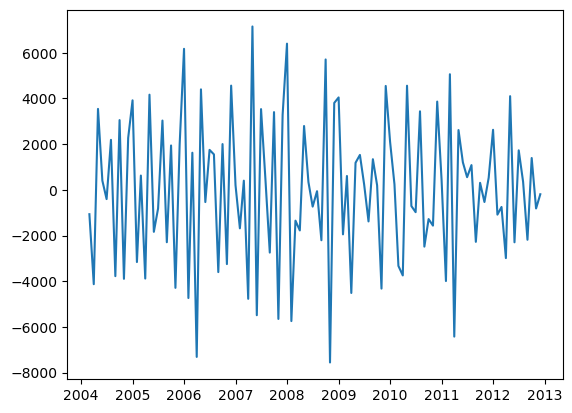

In [18]:
plt.plot(series)

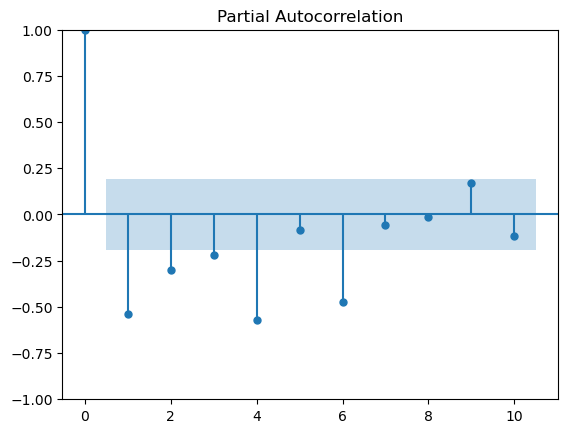

In [19]:
plot_pacf(series, lags=10)
plt.show()

# Either AR(1), AR(4), AR(6), or AR(10)

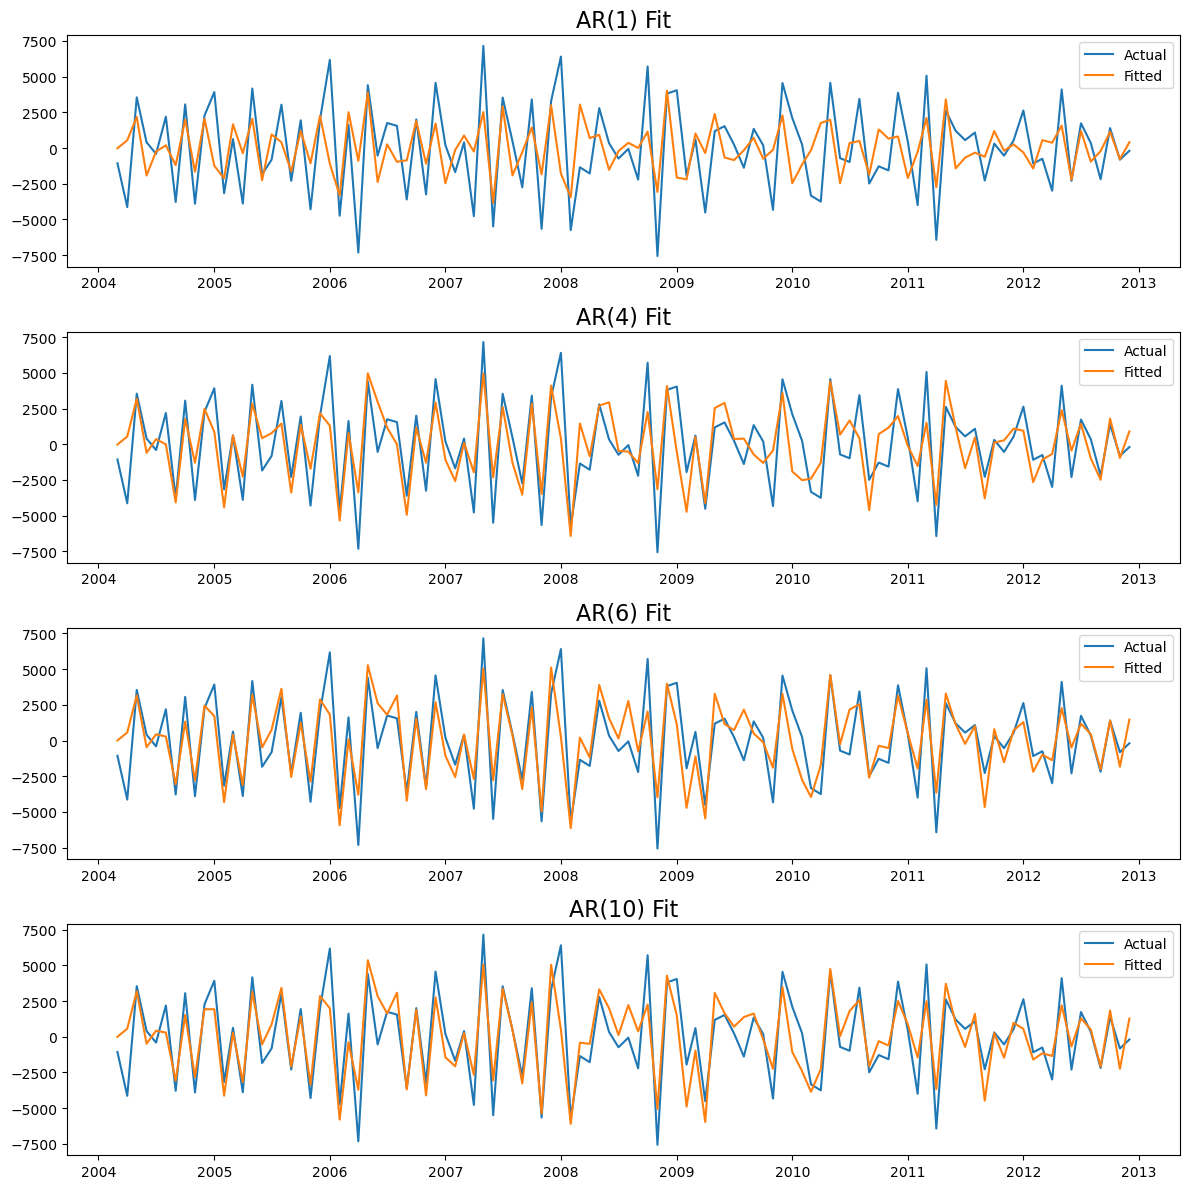

In [22]:


plt.figure(figsize=(12,12))

ar_orders = [1, 4, 6, 10]
fitted_model_dict = {}

for idx, ar_order in enumerate(ar_orders):
    
    # Create AR(p) model: ARIMA(p,0,0)
    ar_model = ARIMA(series, order=(ar_order, 0, 0))
    ar_model_fit = ar_model.fit()
    fitted_model_dict[ar_order] = ar_model_fit
    
    # Plot
    plt.subplot(4, 1, idx + 1)
    plt.plot(series, label='Actual')
    plt.plot(ar_model_fit.fittedvalues, label='Fitted')
    plt.title(f'AR({ar_order}) Fit', fontsize=16)
    plt.legend()

plt.tight_layout()
plt.show()


Each model has: 

a log likelihood ($l$)
a number of parameters ($k$)

a number of samples used for fitting ($n$)

AIC = 2k - 2l

Lower AIC via higher log likelihood or less parameters

BIC = \ln(n)k - 2l

Lower BIC via higher log likelihood or less parameters or less samples used in fitting

## Based on AIC criteria, pick AR(6)

In [23]:
#AIC comparison
for ar_order in ar_orders:
    print('AIC for AR(%s): %s'%(ar_order, fitted_model_dict[ar_order].aic))

AIC for AR(1): 1980.860621744531
AIC for AR(4): 1927.6099852660193
AIC for AR(6): 1899.6497440822495
AIC for AR(10): 1902.3765450112794


## Based on BIC criteria, pick AR(6)

In [10]:
#BIC comparison
for ar_order in ar_orders:
    print('BIC for AR(%s): %s'%(ar_order, fitted_model_dict[ar_order].bic))

BIC for AR(1): 1988.8466278246046
BIC for AR(4): 1943.4313936035905
BIC for AR(6): 1920.9377787387357
BIC for AR(10): 1934.2260603418445
